In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [3]:
py_res_files = glob.glob("./python/fr_final_*cpu.csv")
py_res_dfs = [pd.read_csv(file) for file in py_res_files]
for i, file in enumerate(py_res_files):
    py_res_dfs[i]["num_cpus"] = int(file.split("_")[2].split(".")[0].replace("cpu", ""))
py_res = pd.concat(py_res_dfs)


rs_res_files = glob.glob("./rust/fr_final_fr_final_results_*cpu.csv")
rs_res_dfs = [pd.read_csv(file) for file in rs_res_files]
for i, file in enumerate(rs_res_files):
    rs_res_dfs[i]["num_cpus"] = int(file.split("_")[5].split(".")[0].replace("cpu", ""))

rs_res = pd.concat(rs_res_dfs)

py_res = py_res.sort_values(by="num_cpus")
rs_res = rs_res.sort_values(by="num_cpus")

py_res["tottime"] = py_res["buildtime"] + py_res["querytime"]
rs_res["tottime"] = rs_res["buildtime"] + rs_res["querytime"]

py_res["nprobe"] = py_res["params"].str.extract(r"nprobe=(\d+)").astype(int)
rs_res["nprobe"] = rs_res["params"].str.extract(r"nprobe=(\d+)").astype(int)

print(len(py_res))
py_res.head()

210


,size,algo,kmeanstime,trainmodeltime,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,nvectors,params,recall,num_cpus,tottime,nprobe
0,100M,lmi,656.028039,939.304122,0.0,0.0,0.0,4306.783849,766.638224,279418.2224,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.950267,16,5073.422073,22
1,100M,lmi,656.028039,939.304122,0.0,0.0,0.0,4306.783849,1177.188267,340445.5776,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.957593,16,5483.972117,27
15,100M,lmi,656.028039,939.304122,0.0,0.0,0.0,4306.783849,93.811333,105427.1327,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.888133,16,4400.595182,8
14,100M,lmi,656.028039,939.304122,0.0,0.0,0.0,4306.783849,576.399906,254959.2079,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.946257,16,4883.183755,20
29,100M,lmi,656.028039,939.304122,0.0,0.0,0.0,4306.783849,593.967071,267207.2972,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.948377,16,4900.750921,21


In [4]:
rs_res.head()

,size,algo,kmeanstime,trainmodeltime,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,nvectors,params,recall,num_cpus,tottime,nprobe
0,100M,rust-lmi-task1,989.875495,775.321278,0.0,0.0,0.0,8495.317451,17.429180,154180.9938,rust-lmi-task=1-ds=100M-ep=15-lr=0.00098-sampl...,0.913757,16,8512.746631,12
1,100M,rust-lmi-task1,989.875495,775.321278,0.0,0.0,0.0,8495.317451,11.942178,104361.3127,rust-lmi-task=1-ds=100M-ep=15-lr=0.00098-sampl...,0.883890,16,8507.259630,8
2,100M,rust-lmi-task1,989.875495,775.321278,0.0,0.0,0.0,8495.317451,33.752970,300363.6570,rust-lmi-task=1-ds=100M-ep=15-lr=0.00098-sampl...,0.948333,16,8529.070421,24
3,100M,rust-lmi-task1,989.875495,775.321278,0.0,0.0,0.0,8495.317451,3.537162,14006.0961,rust-lmi-task=1-ds=100M-ep=15-lr=0.00098-sampl...,0.548823,16,8498.854613,1
4,100M,rust-lmi-task1,989.875495,775.321278,0.0,0.0,0.0,8495.317451,3.536355,27441.0348,rust-lmi-task=1-ds=100M-ep=15-lr=0.00098-sampl...,0.698330,16,8498.853807,2


In [5]:
# Group by num_cpus
py_res_grouped = py_res.groupby("num_cpus")
rs_res_grouped = rs_res.groupby("num_cpus")

In [6]:
py_res_grouped["querytime"].mean(), rs_res_grouped["querytime"].mean()

(num_cpus
 16    476.233503
 32    139.918657
 48    132.314742
 56    245.388139
 64    117.476959
 80    395.228950
 96    128.287946
 Name: querytime, dtype: float64,
 num_cpus
 16    22.181774
 32    18.277852
 48    16.398260
 56    20.166559
 64    11.836276
 80    13.664058
 96    16.822514
 Name: querytime, dtype: float64)

In [7]:
py_res[py_res["nprobe"] == 30].groupby("num_cpus")["querytime"].mean()

num_cpus
16    1327.096384
32     267.458764
48     238.152836
56     403.927379
64     227.851369
80     762.986774
96     232.815685
Name: querytime, dtype: float64

In [8]:
rs_res[rs_res["nprobe"] == 30].groupby("num_cpus")["querytime"].mean()

num_cpus
16    41.791934
32    34.399425
48    29.285334
56    37.521777
64    21.622310
80    25.287045
96    31.487643
Name: querytime, dtype: float64

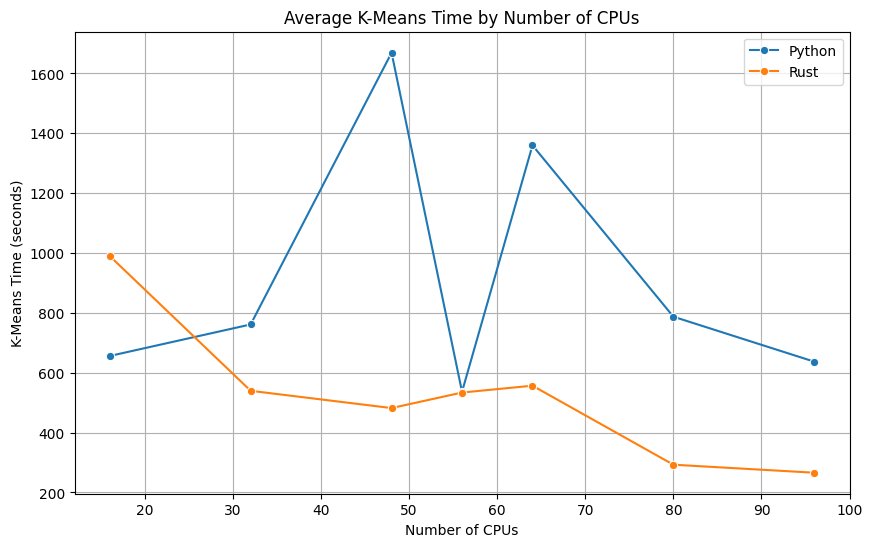

In [15]:
# Convert grouped data to DataFrame for plotting
py_kmeanstime_mean = py_res_grouped['kmeanstime'].mean().reset_index()
rs_kmeanstime_mean = rs_res_grouped['kmeanstime'].mean().reset_index()

# Plot the average buildtime grouped by num_cpus in a single line chart
plt.figure(figsize=(10, 6))
sns.lineplot(x='num_cpus', y='kmeanstime', data=py_kmeanstime_mean, marker='o', label='Python')
sns.lineplot(x='num_cpus', y='kmeanstime', data=rs_kmeanstime_mean, marker='o', label='Rust')
plt.title('Average K-Means Time by Number of CPUs')
plt.xlabel('Number of CPUs')
plt.ylabel('K-Means Time (seconds)')
plt.grid(True)
plt.legend()
plt.savefig('../cpu_kmeans.png', dpi=300, bbox_inches='tight')
plt.show()

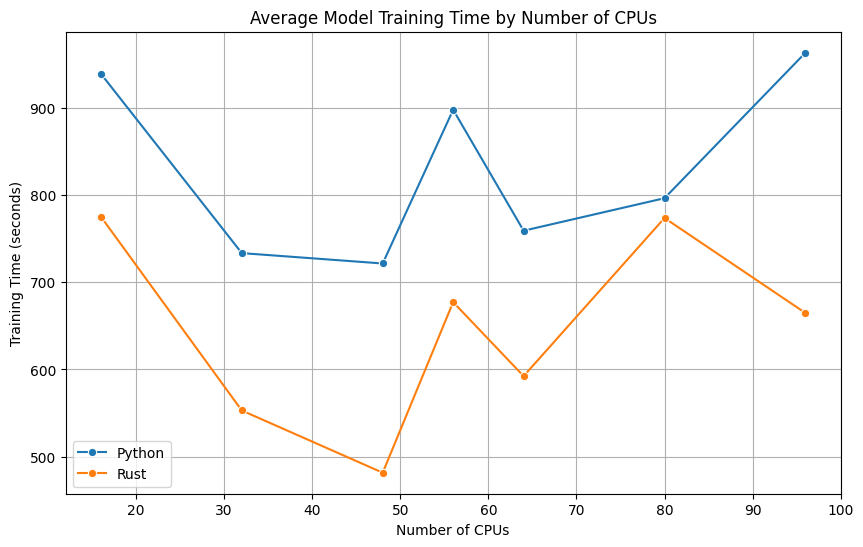

In [16]:
# Convert grouped data to DataFrame for plotting
py_trainmodeltime_mean = py_res_grouped['trainmodeltime'].mean().reset_index()
rs_trainmodeltime_mean = rs_res_grouped['trainmodeltime'].mean().reset_index()

# Plot the average trainmodeltime grouped by num_cpus in a single line chart
plt.figure(figsize=(10, 6))
sns.lineplot(x='num_cpus', y='trainmodeltime', data=py_trainmodeltime_mean, marker='o', label='Python')
sns.lineplot(x='num_cpus', y='trainmodeltime', data=rs_trainmodeltime_mean, marker='o', label='Rust')
plt.title('Average Model Training Time by Number of CPUs')
plt.xlabel('Number of CPUs')
plt.ylabel('Training Time (seconds)')
plt.grid(True)
plt.legend()
plt.savefig('../cpu_trainmodel.png', dpi=300, bbox_inches='tight')
plt.show()


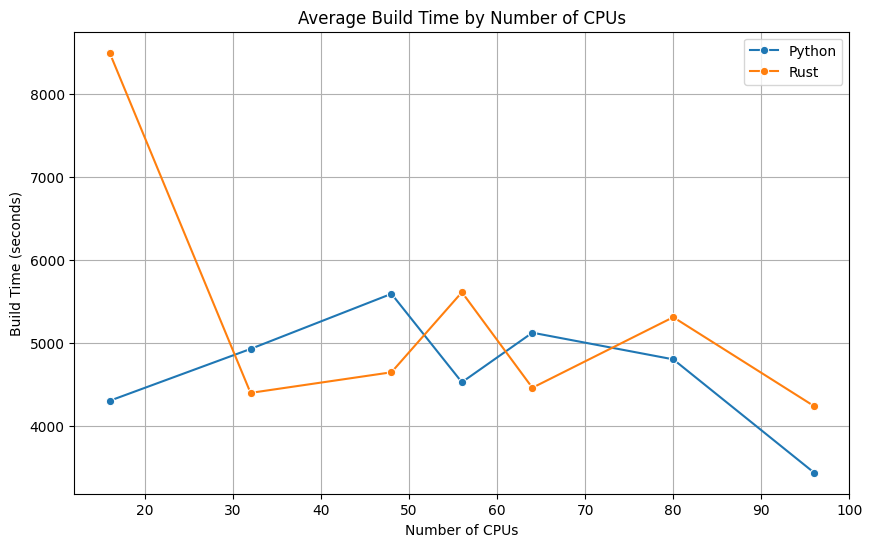

In [17]:
# Convert grouped data to DataFrame for plotting
py_buildtime_mean = py_res_grouped['buildtime'].mean().reset_index()
rs_buildtime_mean = rs_res_grouped['buildtime'].mean().reset_index()

# Plot the average buildtime grouped by num_cpus in a single line chart
plt.figure(figsize=(10, 6))
sns.lineplot(x='num_cpus', y='buildtime', data=py_buildtime_mean, marker='o', label='Python')
sns.lineplot(x='num_cpus', y='buildtime', data=rs_buildtime_mean, marker='o', label='Rust')
plt.title('Average Build Time by Number of CPUs')
plt.xlabel('Number of CPUs')
plt.ylabel('Build Time (seconds)')
plt.grid(True)
plt.legend()
plt.savefig('../cpu_build.png', dpi=300, bbox_inches='tight')
plt.show()


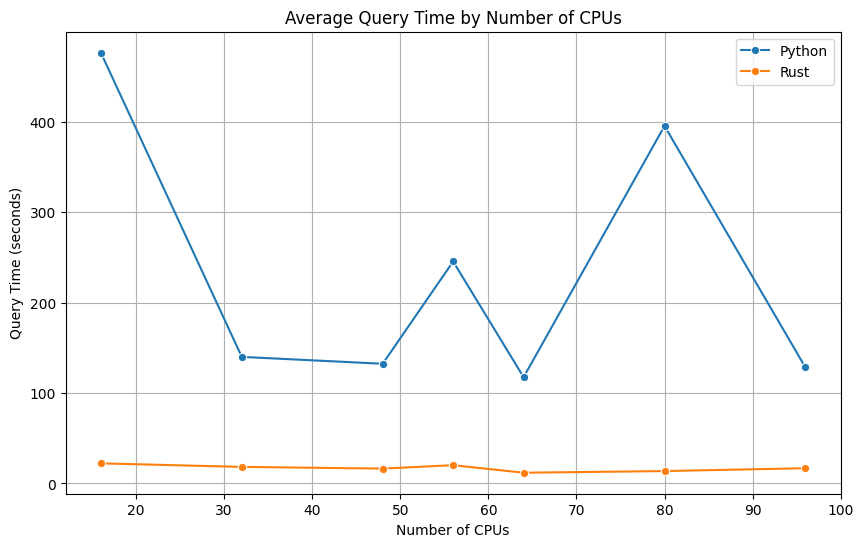

In [18]:
# Convert grouped data to DataFrame for plotting
py_querytime_mean = py_res_grouped["querytime"].mean().reset_index()
rs_querytime_mean = rs_res_grouped["querytime"].mean().reset_index()

# Plot the average querytime grouped by num_cpus in a single line chart
plt.figure(figsize=(10, 6))
sns.lineplot(x="num_cpus", y="querytime", data=py_querytime_mean, marker='o', label="Python")
sns.lineplot(x="num_cpus", y="querytime", data=rs_querytime_mean, marker='o', label="Rust")
plt.title("Average Query Time by Number of CPUs")
plt.xlabel("Number of CPUs")
plt.ylabel("Query Time (seconds)")
plt.grid(True)
plt.legend()
plt.savefig('../cpu_query.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
rs_querytime_mean

,num_cpus,querytime
0,16,22.181774
1,32,18.277852
2,48,16.398260
3,56,20.166559
4,64,11.836276
5,80,13.664058
6,96,16.822514
